In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [4]:
le_sex = LabelEncoder()
df['Sex']=le_sex.fit_transform(df['Sex'])

le_ChestPainType = LabelEncoder()
df['ChestPainType'] = le_ChestPainType.fit_transform(df['ChestPainType'])

le_RestingECG = LabelEncoder()
df['RestingECG']=le_RestingECG.fit_transform(df['RestingECG'])

le_ExerciseAngina = LabelEncoder()
df['ExerciseAngina']=le_ExerciseAngina.fit_transform(df['ExerciseAngina'])

le_ST_Slope = LabelEncoder()
df['ST_Slope']=le_ST_Slope.fit_transform(df['ST_Slope'])


In [5]:
le_sex.classes_

array(['F', 'M'], dtype=object)

In [6]:
le_ChestPainType.classes_

array(['ASY', 'ATA', 'NAP', 'TA'], dtype=object)

In [7]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [8]:
class_names=['Normal', 'Heart Disease']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,random_state=42,test_size=0.2
)

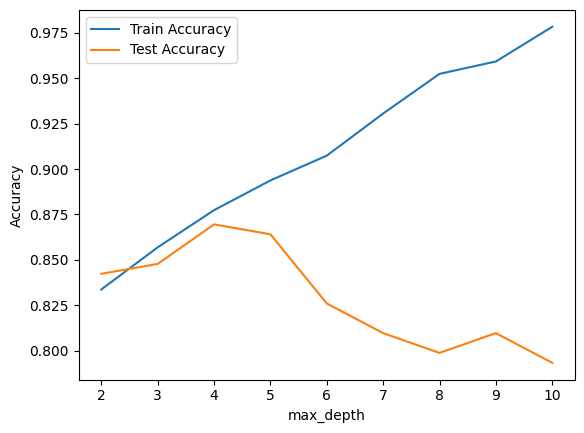

In [10]:
import matplotlib.pyplot as plt

depths = [2,3,4,5,6,7,8,9,10]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [11]:
best_depth = 2 
model = DecisionTreeClassifier(max_depth= best_depth, random_state=42 )
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
y_pred = model.predict(X_test)

In [13]:
y_pred_proba = model.predict_proba(X_test)

In [14]:
print("Confusion Matrix is :", confusion_matrix(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("Classification Report",classification_report(y_test,y_pred))

Confusion Matrix is : [[61 16]
 [13 94]]
accuracy_score: 0.842391304347826
Classification Report               precision    recall  f1-score   support

           0       0.82      0.79      0.81        77
           1       0.85      0.88      0.87       107

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [15]:
model.score(X_train,y_train)

0.8337874659400545

In [16]:
model.score(X_train, y_train)   # ab yeh 1.0 nahi aana chahiye
model.score(X_test, y_test)

0.842391304347826

In [17]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

           Feature  Importance
10        ST_Slope    0.809342
4      Cholesterol    0.104507
2    ChestPainType    0.086151
1              Sex    0.000000
0              Age    0.000000
5        FastingBS    0.000000
3        RestingBP    0.000000
6       RestingECG    0.000000
7            MaxHR    0.000000
8   ExerciseAngina    0.000000
9          Oldpeak    0.000000


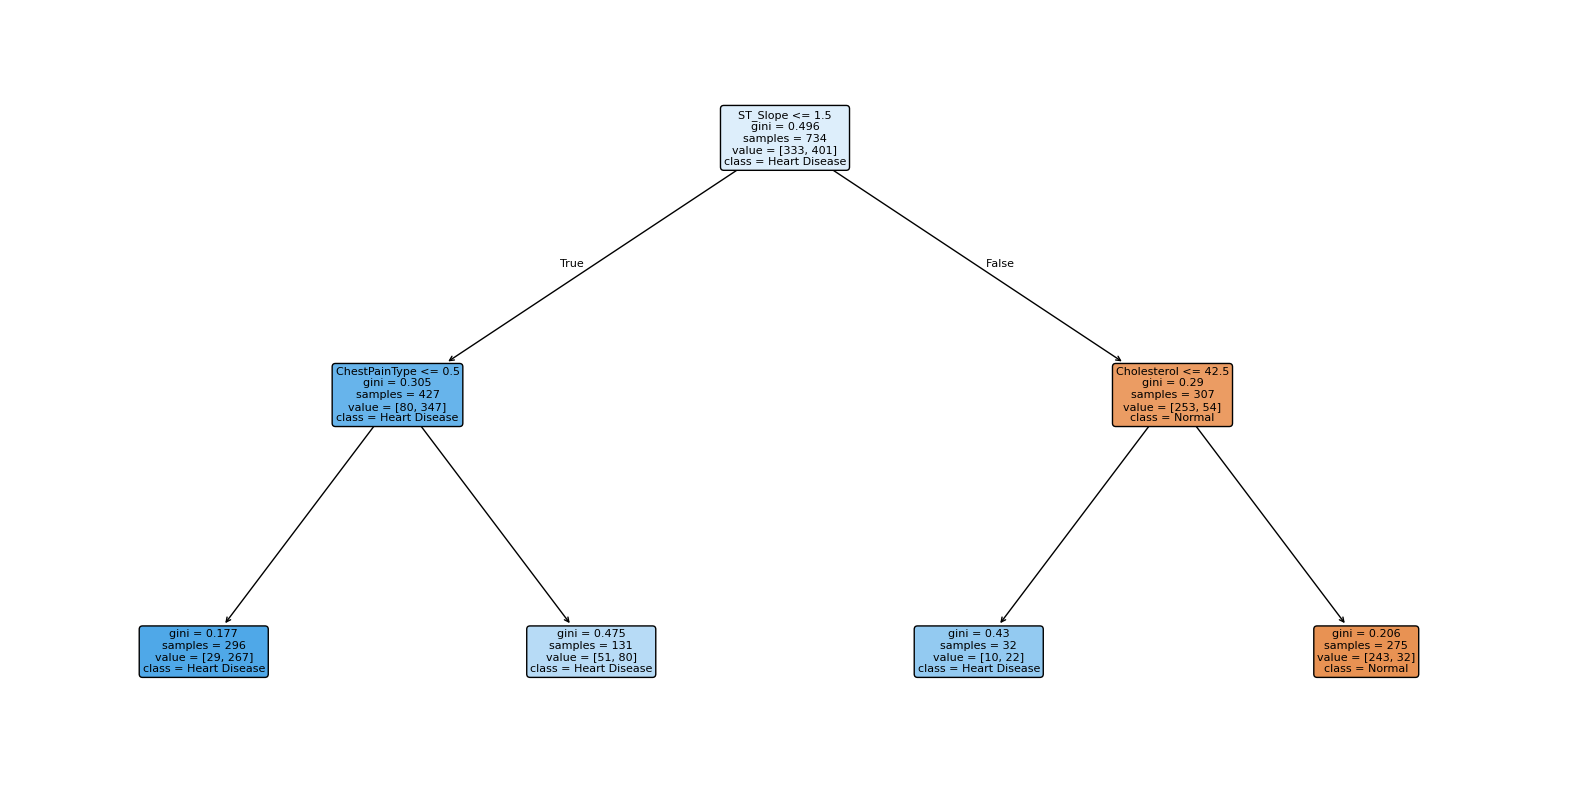

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X_train.columns, class_names=['Normal', 'Heart Disease'], filled=True, rounded=True, fontsize=8)
plt.show()